#### PCA - Principal Component Analysis

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# load data 
df = pd.read_csv("housing_with_ratio_features.csv")

df.head()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,bedrooms_to_rooms_ratio,households_to_population_ratio
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1,0.146591,0.391304
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1,0.155797,0.473969
2,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1,0.129516,0.356855
3,52.0,1274.0,558.0,5.6431,341300.0,17.06,0,0,0,1,0.184458,0.392473
4,52.0,1627.0,565.0,3.8462,342200.0,17.06,0,0,0,1,0.172096,0.458407


In [9]:
len(df.columns)

12

### Scale the values and perform PCA on our data (X/y)

Explained variance ratio with 8 components, by each component:
[0.20950896 0.19700541 0.14053134 0.12586563 0.09121447 0.09029657
 0.05542354 0.04250012]

Explained variance ratio with 8 components, total result:
0.9523460422832706

Mean Squared Error (MSE) between original and reconstructed data:
0.04765395771672932
Average MSE per feature: 0.004332


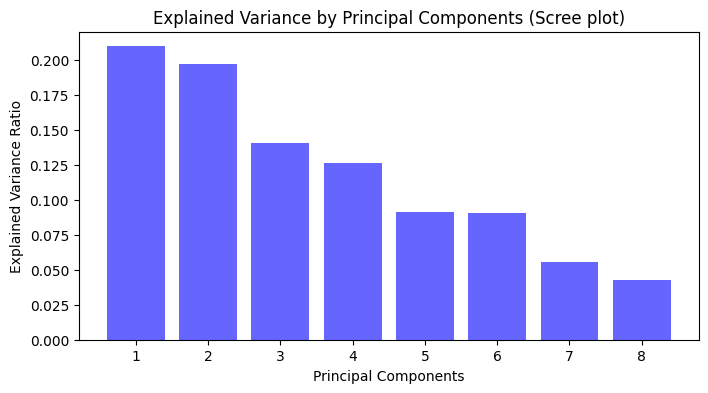

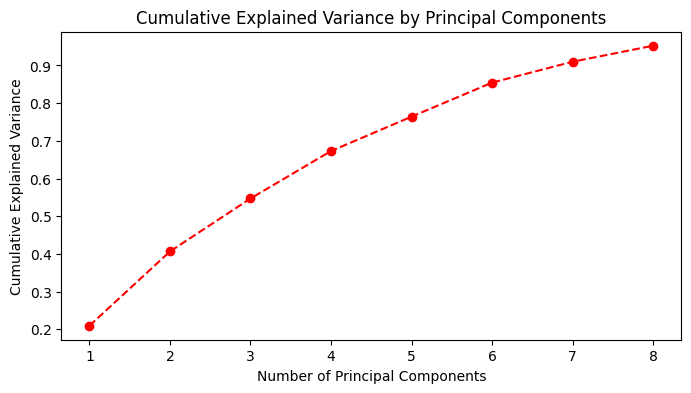

In [10]:
# X/y -split and scale the values
X = df.drop("median_house_value", axis=1)
y = df['median_house_value']

# scaling is needed in PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# define amount of PCA-variables => principal components
num_components = 8

# train the PCA -model
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_columns = [f"PC{i+1}" for i in range(num_components)]

pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Add the target variable back
pca_df["median_house_value"] = y.values

# some basic metrics
explained_variance_ratio = pca.explained_variance_ratio_

print(f"Explained variance ratio with {num_components} components, by each component:\n{explained_variance_ratio}")
print(f"\nExplained variance ratio with {num_components} components, total result:\n{sum(explained_variance_ratio)}")

# 0.798 ~~ 80% of data preserved, which means we lost 20% of variance in the process
# aim to have less than 10% lost, or even less than 5% lost

X_reconstructed = pca.inverse_transform(X_pca)

# other metric is MSE => keep this as close to 0 as possible
# basically measures how much error the PCA model makes compared to original data
mse = mean_squared_error(X_scaled, X_reconstructed)
print(f"\nMean Squared Error (MSE) between original and reconstructed data:\n{mse}")
print(f"Average MSE per feature: {mse / X_scaled.shape[1]:.6f}")
# plot variance plots to see how much different components add to explainability
# plot 1: SCREE PLOT
plt.figure(figsize=(8, 4))
plt.bar(range(1, num_components + 1, ), explained_variance_ratio, alpha=0.6, color="b")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components (Scree plot)")
plt.show()

# plot 2: cumulative explained variance
cumulative_variance = explained_variance_ratio.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_components + 1, ), cumulative_variance, marker="o", linestyle='--', color="r")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.show()

In [11]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,median_house_value
0,-1.937118,0.134699,-3.193320,2.001711,-0.385434,-0.470430,-0.636816,0.014084,452600.0
1,0.051849,2.576177,-1.926408,3.394979,0.219858,0.317416,-0.741454,-0.095746,358500.0
2,-2.089338,0.061948,-2.973203,2.096347,-0.792829,-1.030310,0.076372,0.402028,352100.0
3,-2.226560,-0.542568,-1.871616,2.364162,-0.646057,-0.766622,-0.018279,0.325815,341300.0
4,-2.119181,-0.854469,-1.461537,2.726013,-0.380429,-0.375071,0.243487,0.481783,342200.0


In [12]:
# get the component loadings
loadings = pca.components_

# create a DataFrame
loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f"PC{i + 1}" for i in range(loadings.shape[0])], index=X.columns
)

In [13]:
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
housing_median_age,-0.419598,-0.196492,-0.022821,0.140269,-0.176824,-0.252035,0.757991,0.251637
total_rooms,0.317805,0.493527,0.162958,0.303005,0.036407,0.029701,0.235280,0.079972
population,0.268443,0.467239,0.370158,0.209325,-0.120708,-0.168550,0.129274,0.076254
median_income,-0.061571,0.390649,-0.570619,-0.051301,0.083564,0.076127,-0.004809,-0.149033
distance_to_nearest_city,0.464941,-0.277152,-0.054113,-0.132184,0.087559,0.111127,-0.055263,0.748664
ocean_proximity_<1H OCEAN,-0.339058,0.338398,0.200334,-0.453677,0.113919,0.167053,0.016463,0.128389
ocean_proximity_INLAND,0.489891,-0.300837,-0.077790,-0.014114,-0.088498,-0.110017,0.265504,-0.514673
ocean_proximity_ISLAND,-0.011691,-0.018037,0.017072,0.017544,0.803001,-0.594211,-0.021964,-0.003823
ocean_proximity_NEAR BAY,-0.217753,-0.036132,-0.177658,0.670871,-0.164127,-0.170119,-0.423204,0.155829
bedrooms_to_rooms_ratio,-0.159754,-0.229172,0.654694,0.090499,0.042339,0.087382,-0.191510,-0.182468


<Axes: >

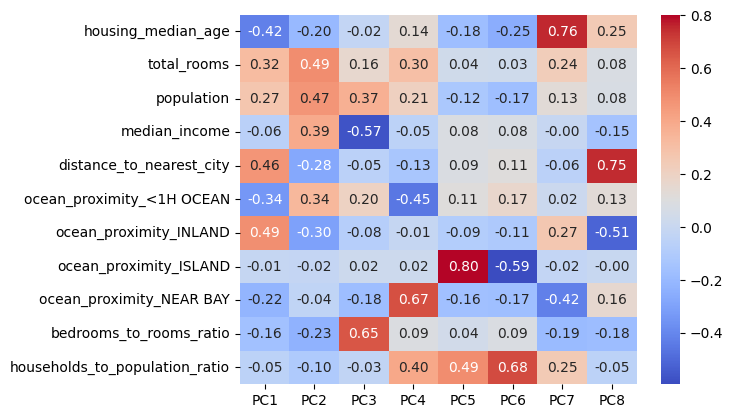

In [14]:
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="coolwarm")

### Data Analysis - point of view -> finding noise etc.

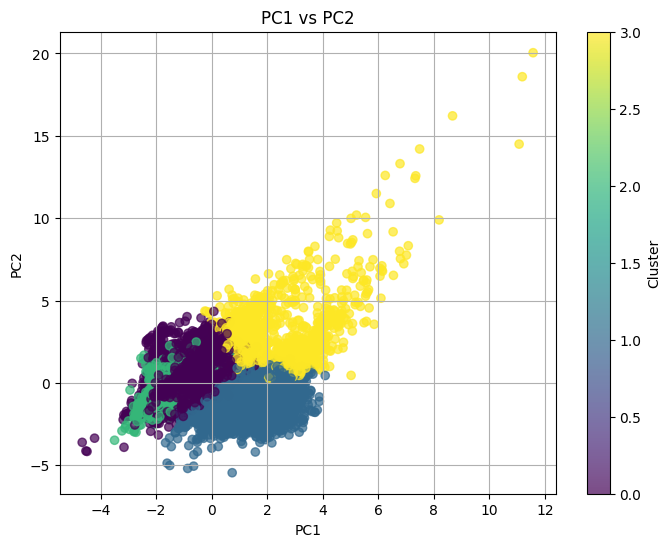

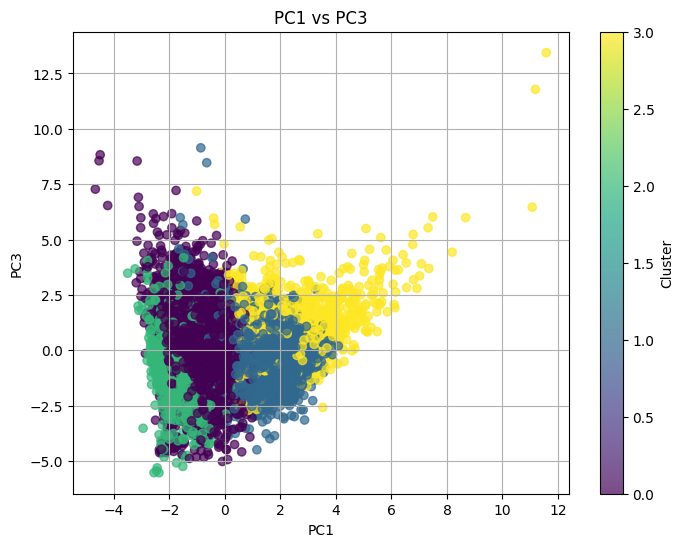

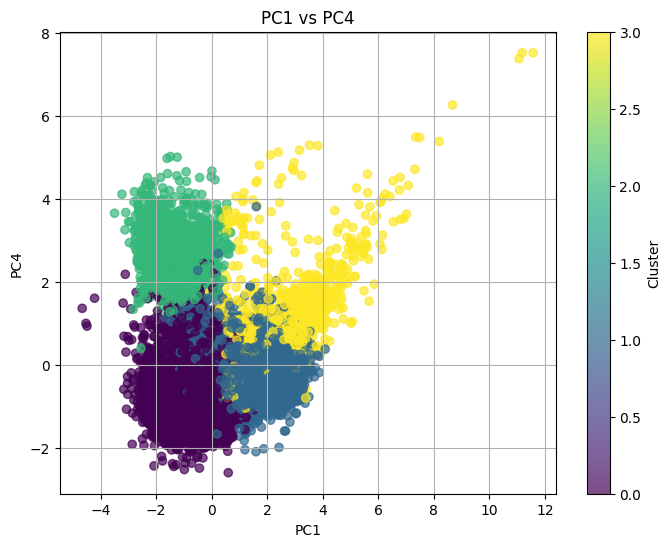

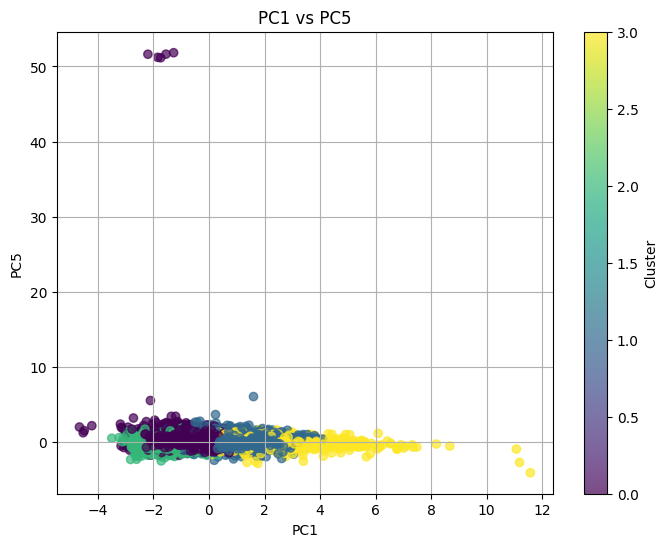

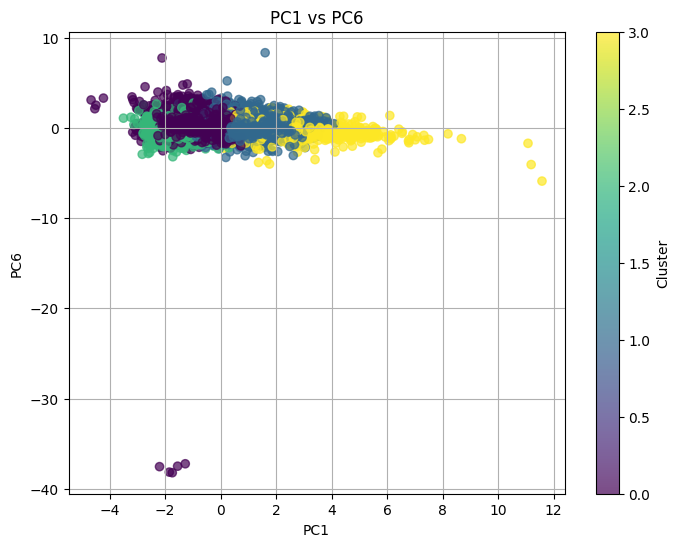

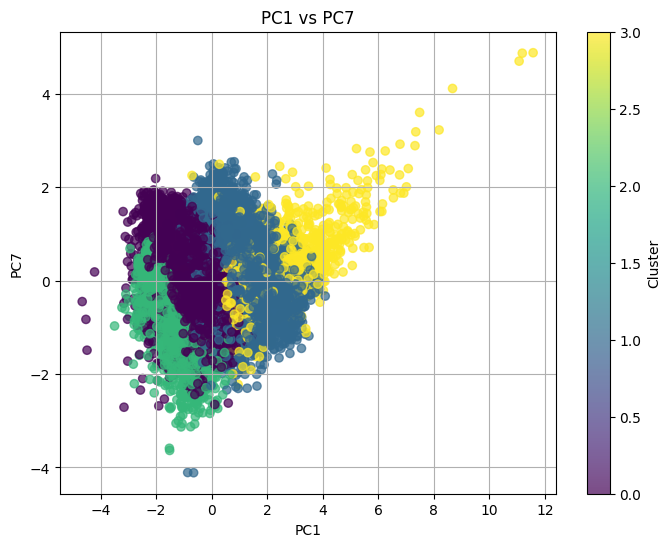

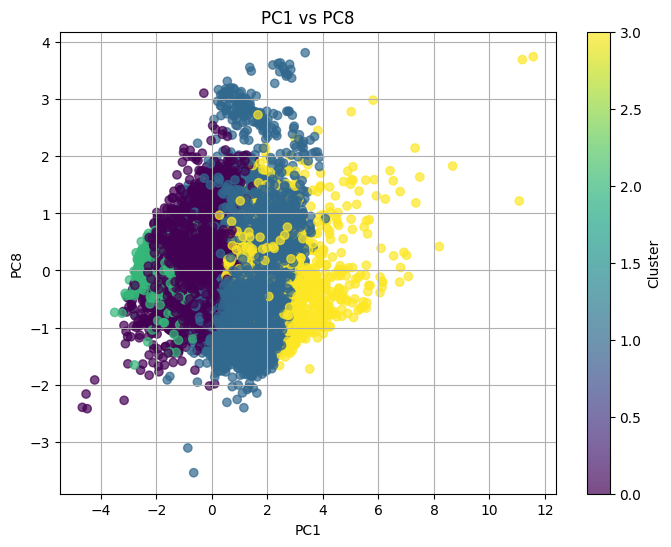

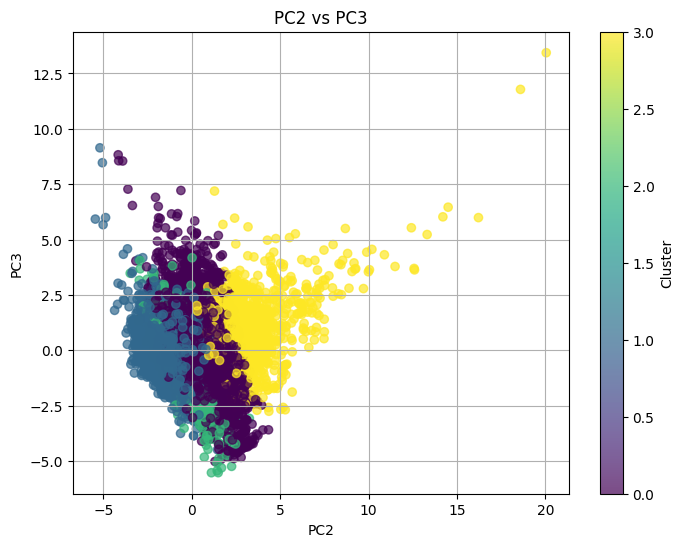

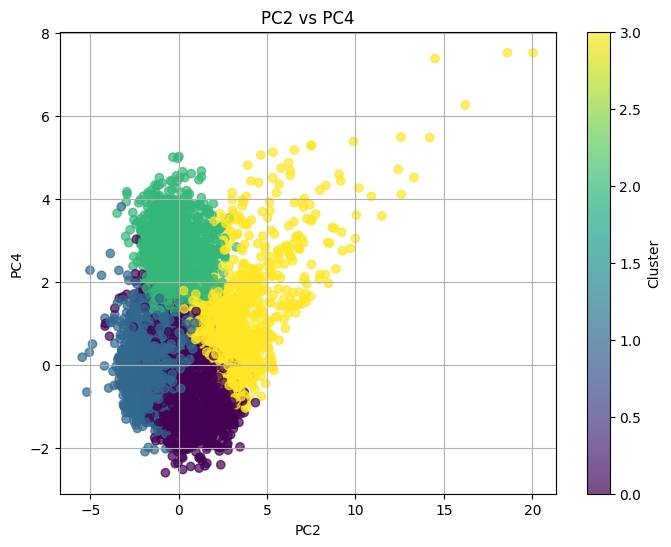

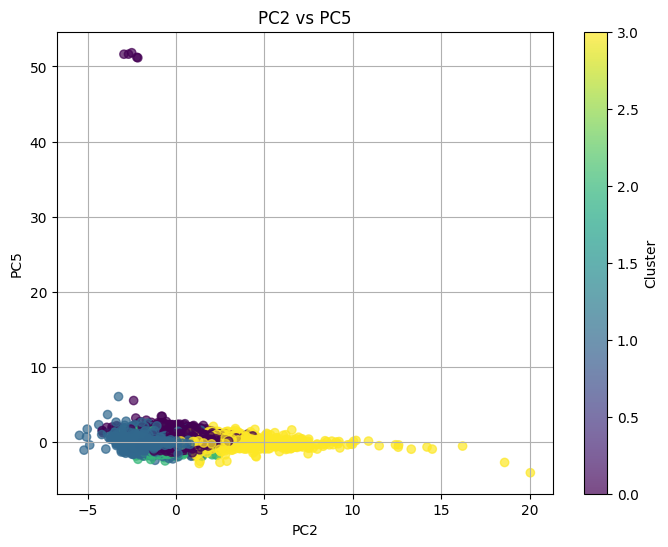

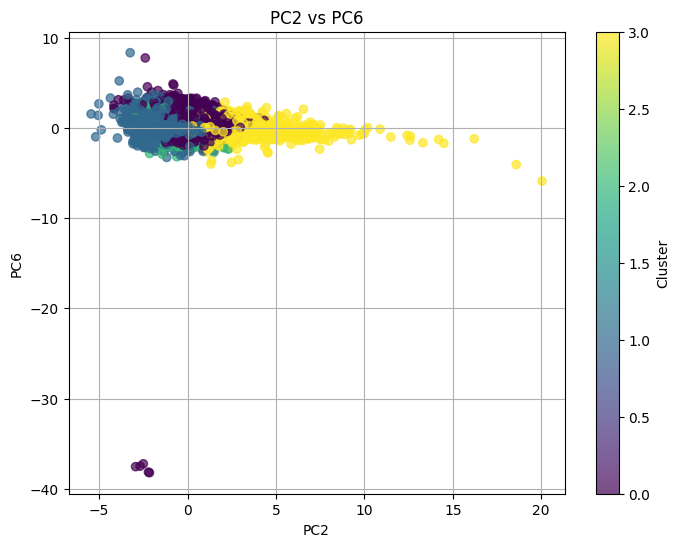

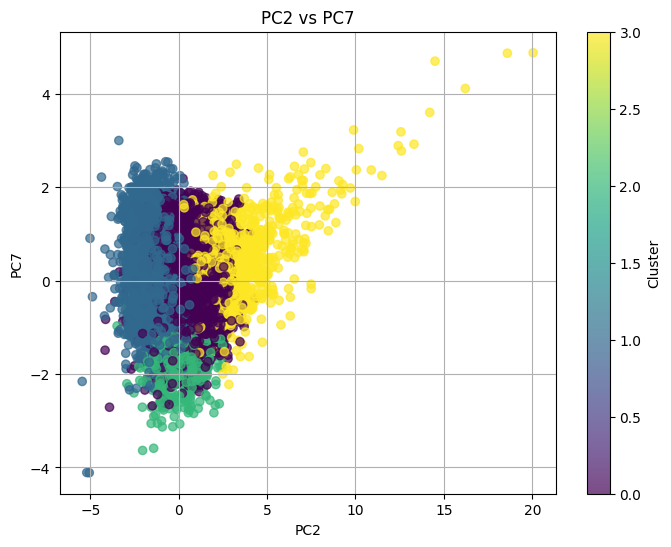

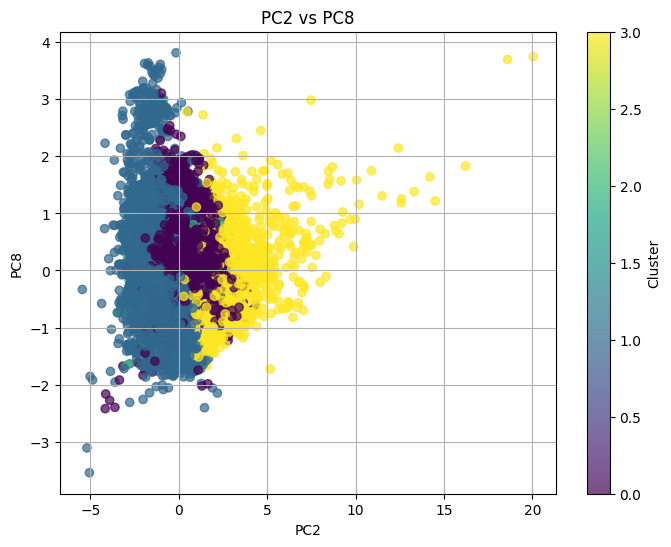

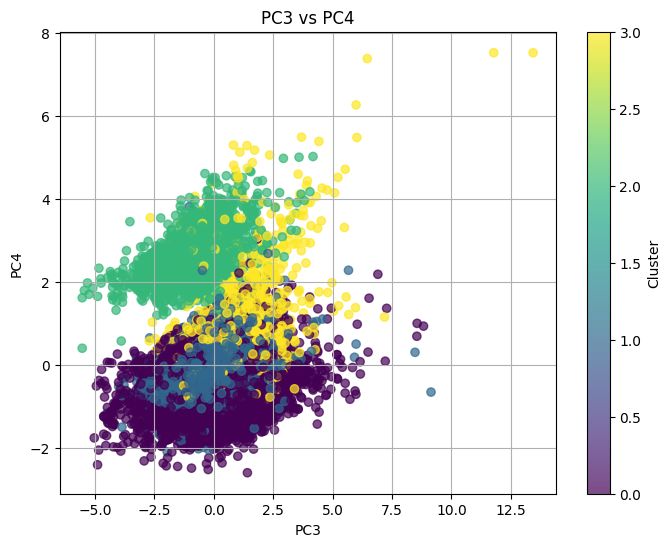

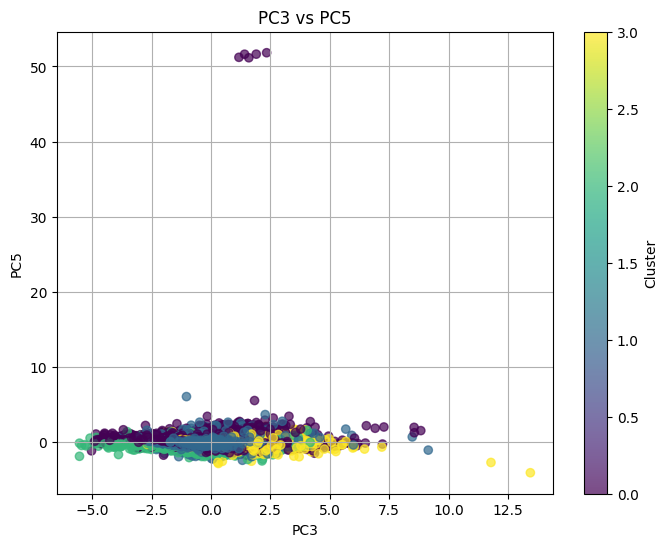

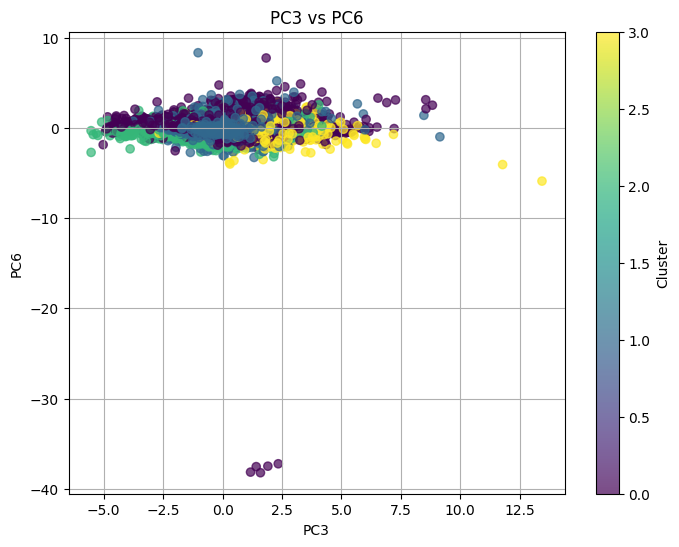

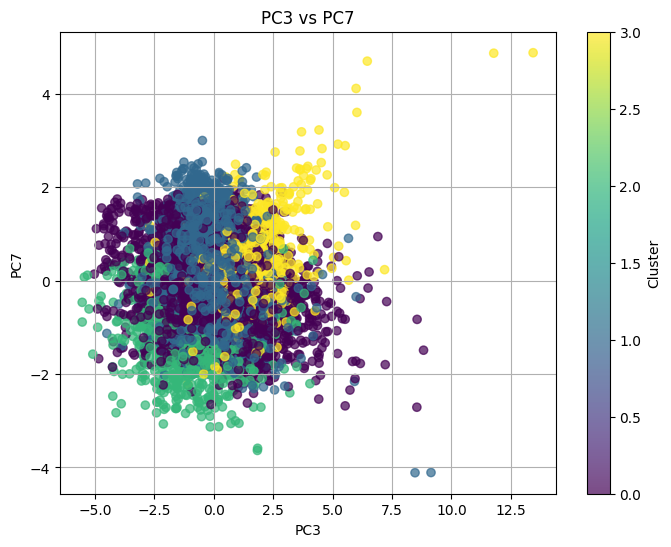

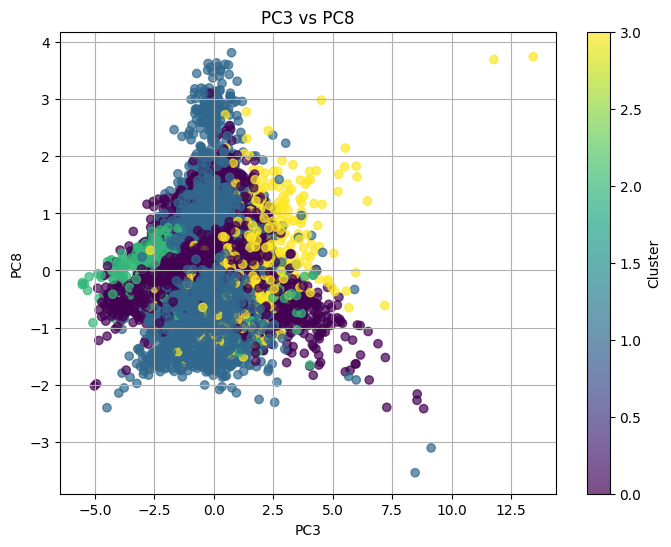

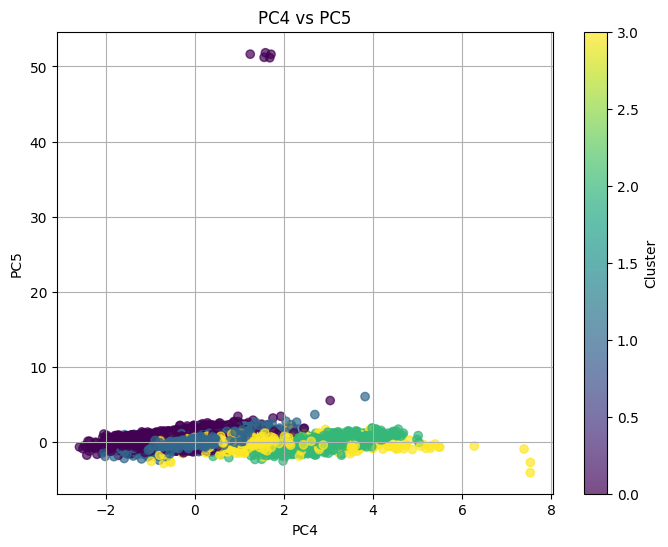

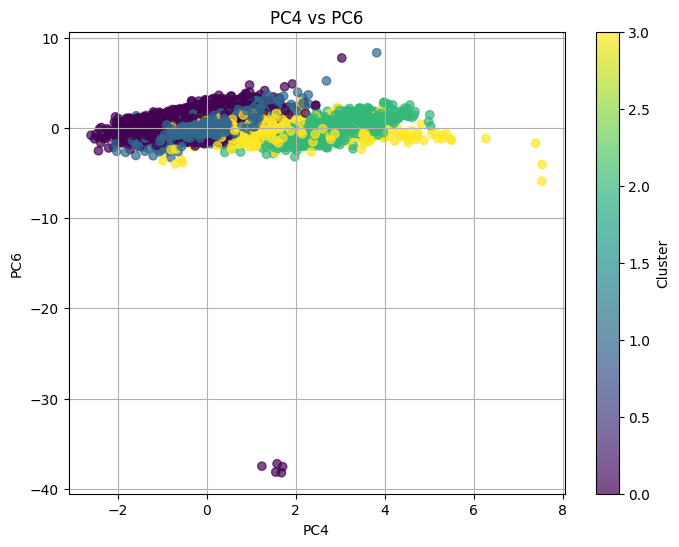

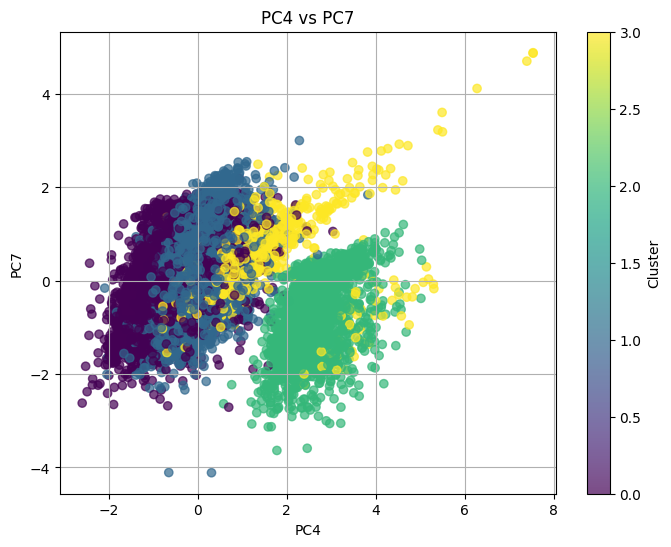

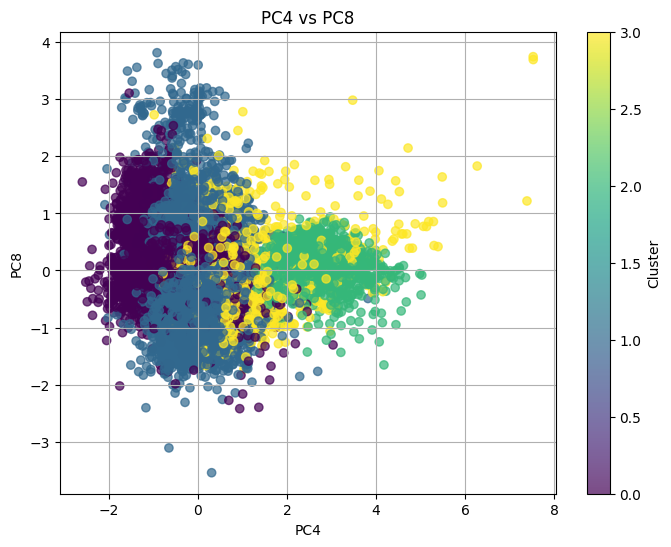

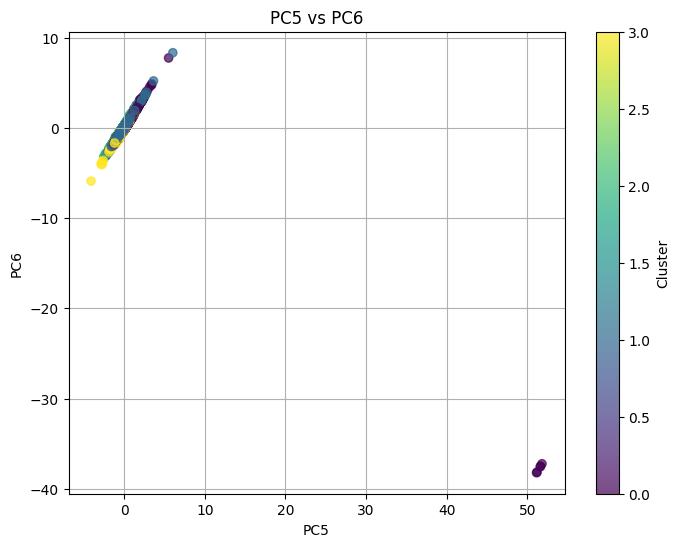

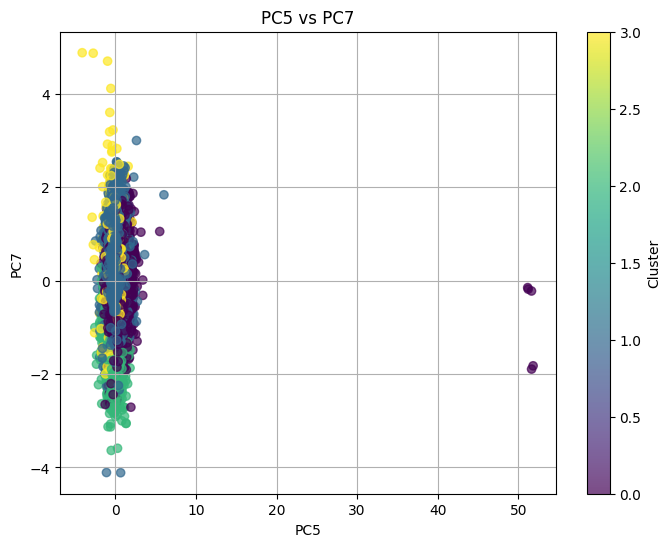

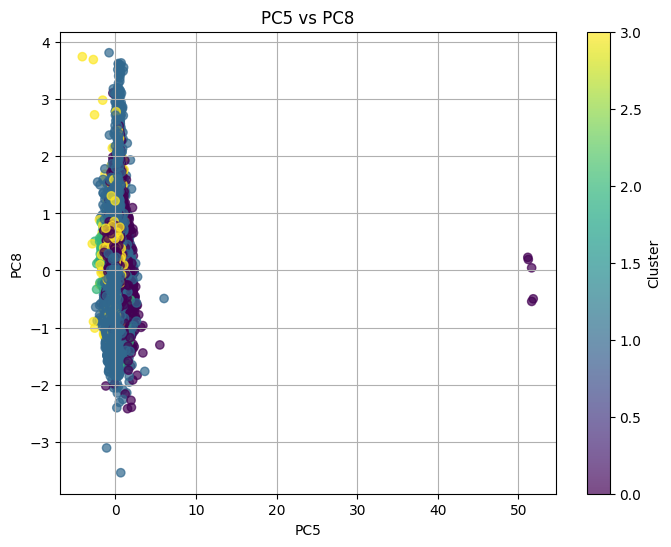

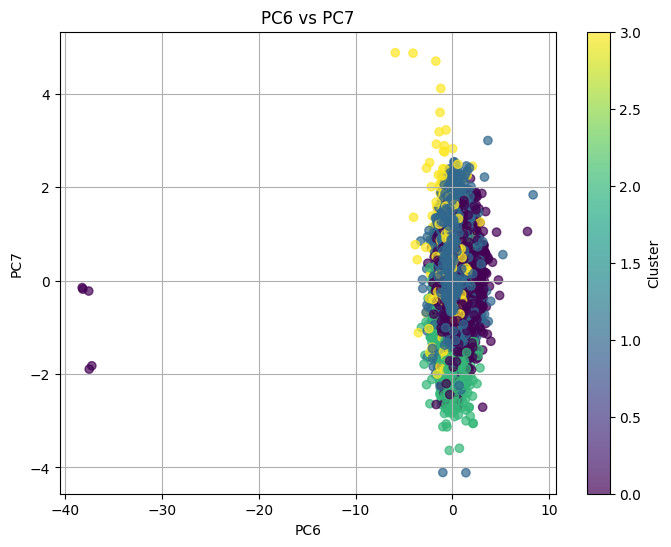

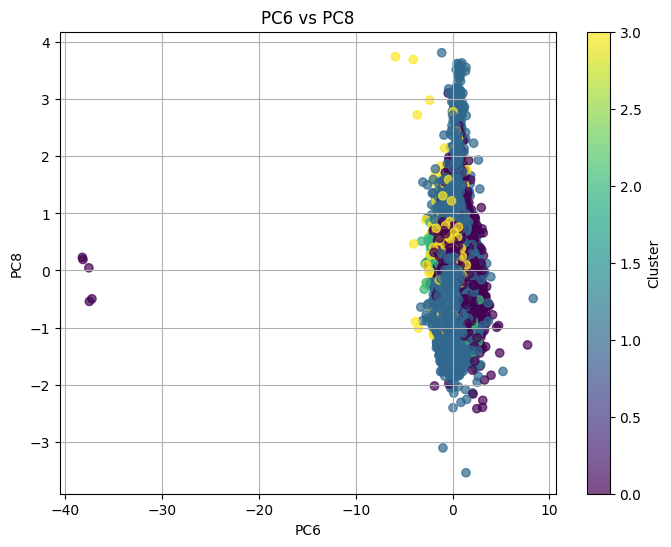

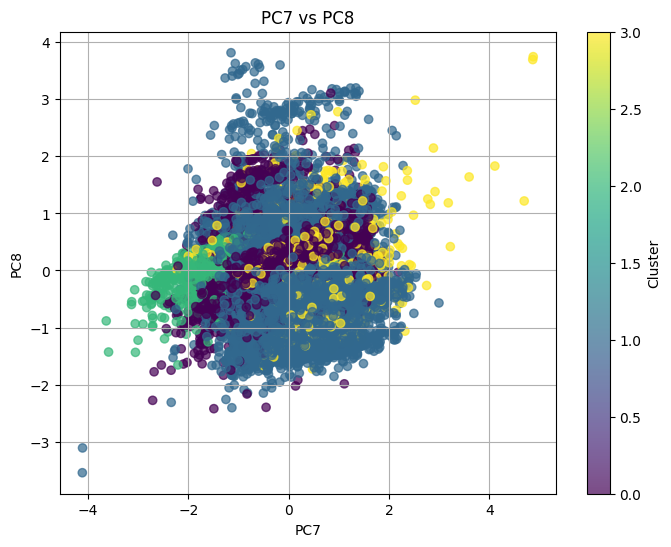

In [15]:
# helper function to compare and visualize PC-variables


def plot_pca_pairs(pca_result, components):
    num_c = pca_result.shape[1]

    # process each pair of PC-variables
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            plt.scatter(pca_result[:, i], pca_result[:, j], alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.show()


def plot_pca_pairs_with_clustering(pca_result, components, n_clusters=3):
    num_c = pca_result.shape[1]
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)
    
    # Process each pair of PC-variables and plot clusters
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(pca_result[:, i], pca_result[:, j], c=cluster_labels, cmap='viridis', alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.colorbar(scatter, label='Cluster')
            plt.show()

# plot_pca_pairs(X_pca, pca.components_)
# we can also use KMeans to visualize how well the data can be differentiated
# 3 is a good number to begin with for clusters, try also 6 (amount of options in the target)
plot_pca_pairs_with_clustering(X_pca, pca.components_, n_clusters=4)

In [ ]:
# with help of Chatgpt:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Linear regression model with PCA features
X_pca_model = pca_df.drop("median_house_value", axis=1)
y_pca = pca_df["median_house_value"]

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_model, y_pca, test_size=0.2, random_state=42
)

model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train_pca)

pred_pca = model_pca.predict(X_test_pca)

print("\nPCA Features")
print("R2:", r2_score(y_test_pca, pred_pca))
print("RMSE:", mean_squared_error(y_test_pca, pred_pca)**0.5)


PCA Features
R2: 0.6114865285671951
RMSE: 72890.2734228578
